# Netflix Data Analysis

This project explores the Netflix dataset to uncover insights about content distribution, genres, and trends over time using Python.

Import libraries

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

Load dataset

In [25]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Exploring the Dataset

We inspect the dataset structure, columns, and data types to understand the data before performing any analysis.

In [37]:
df["listed_in"] = df["listed_in"].str.strip()
df["listed_in"].head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8807 non-null   object 
 1   type          8807 non-null   object 
 2   title         8807 non-null   object 
 3   director      6173 non-null   object 
 4   cast          7982 non-null   object 
 5   country       7976 non-null   object 
 6   date_added    8797 non-null   object 
 7   release_year  8807 non-null   int64  
 8   rating        8803 non-null   object 
 9   duration      8804 non-null   object 
 10  listed_in     0 non-null      float64
 11  description   8807 non-null   object 
dtypes: float64(1), int64(1), object(10)
memory usage: 825.8+ KB


## Data Cleaning

The dataset may contain inconsistencies such as extra spaces or multiple values in a single column. We clean and prepare the data for analysis.

In [27]:
df["listed_in"] = df["listed_in"].str.split(",")
df["listed_in"].head()

0                                      [Documentaries]
1    [International TV Shows,  TV Dramas,  TV Myste...
2    [Crime TV Shows,  International TV Shows,  TV ...
3                            [Docuseries,  Reality TV]
4    [International TV Shows,  Romantic TV Shows,  ...
Name: listed_in, dtype: object

## Splitting Genre Column

The 'listed_in' column contains multiple genres separated by commas. We split these into lists for further processing.

In [28]:
df_exploded = df.explode("listed_in")
df_exploded["listed_in"].head()

0             Documentaries
1    International TV Shows
1                 TV Dramas
1              TV Mysteries
2            Crime TV Shows
Name: listed_in, dtype: object

## Transforming Data with Explode

We convert each list of genres into separate rows so that each row contains only one genre. This allows accurate counting and analysis.

In [29]:
df_exploded["listed_in"] = df_exploded["listed_in"].str.strip()

## Analyzing Most Popular Genres

We calculate the frequency of each genre to identify the most common types of content available on Netflix.

In [30]:
df_exploded["listed_in"].value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

## Visualizing Top Genres

We use a bar chart to visualize the top 10 most popular genres on Netflix.

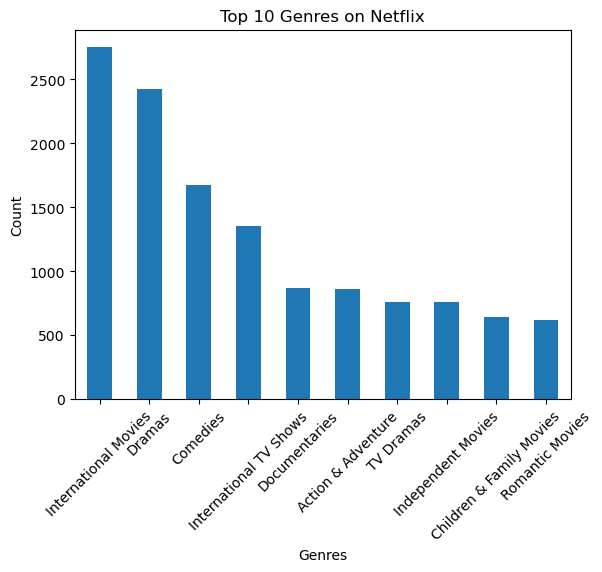

In [31]:
top_genres = df_exploded["listed_in"].value_counts().head(10)

top_genres.plot(kind="bar")

import matplotlib.pyplot as plt
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genres")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Movies vs TV Shows Distribution

We analyze the proportion of Movies and TV Shows available on Netflix.

In [32]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

## Visualizing Content Type Distribution

A pie chart is used to show the percentage distribution of Movies and TV Shows.

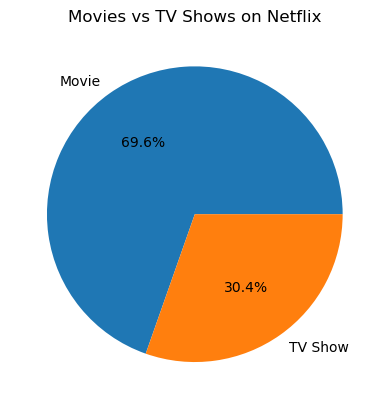

In [33]:
type_counts = df["type"].value_counts()

type_counts.plot(kind="pie", autopct="%1.1f%%")

import matplotlib.pyplot as plt
plt.title("Movies vs TV Shows on Netflix")
plt.ylabel("")  # removes extra label
plt.show()

## Content Growth Over Time

We analyze how the number of Netflix titles has changed over the years.

In [34]:
df["release_year"].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

## Visualizing Growth Trend

A line chart is used to show the trend of content releases over time.

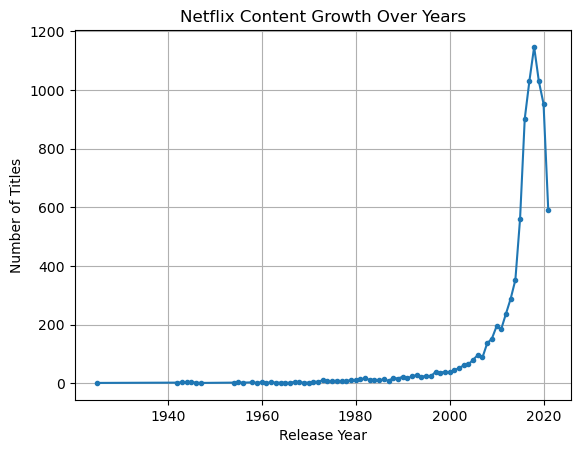

In [40]:
# Count titles per year and sort by year
growth = df["release_year"].value_counts().sort_index()

# Plotting the trend
growth.plot(kind="line", marker='.')

plt.title("Netflix Content Growth Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

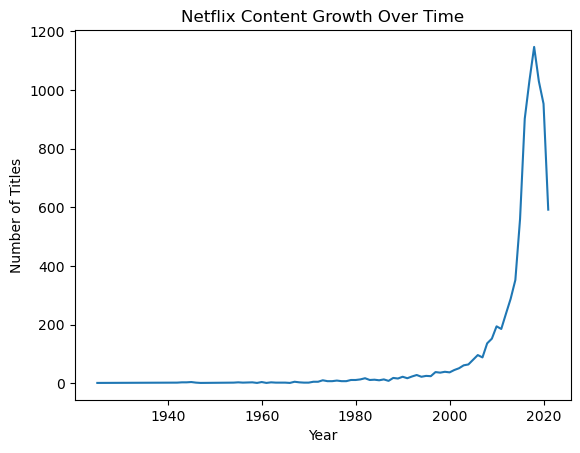

In [36]:
year_counts = df["release_year"].value_counts().sort_index()

year_counts.plot(kind="line")

import matplotlib.pyplot as plt
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

## Key Insights

- Drama and International Movies are among the most common genres.
- Netflix content has grown significantly over the years.
- Movies are more prevalent than TV Shows on the platform.

This analysis demonstrates how data can be used to uncover meaningful patterns and trends.